## Compare Distributions

In [1]:
# imports and configurations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


work_dir = "/jumbo/keller-lab/Jeremy_Wang/eplus_sa/scripts/main" # Change this to your working directory

In [15]:
# Load the data
for seed in range(1, 6):
    seed_name = f"seed_{seed}"
    normal_indices = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )
    uniform_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )
    beta_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )
    # append
    if seed == 1:
        all_normal_indices = normal_indices
        all_uniform_indices = uniform_indices
        all_beta_indices = beta_indices
    else:
        all_normal_indices = pd.concat([all_normal_indices, normal_indices], ignore_index=True)
        all_uniform_indices = pd.concat([all_uniform_indices, uniform_indices], ignore_index=True)
        all_beta_indices = pd.concat([all_beta_indices, beta_indices], ignore_index=True)

In [16]:
all_dfs = []

# Load all distributions + seeds
for seed in range(1, 6):

    seed_name = f"seed_{seed}"

    # -----------------------------
    # Normal
    # -----------------------------
    normal_df = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )

    normal_df["distribution"] = "Normal"
    normal_df["seed"] = seed

    all_dfs.append(normal_df)

    # -----------------------------
    # Uniform
    # -----------------------------
    uniform_df = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )

    uniform_df["distribution"] = "Uniform"
    uniform_df["seed"] = seed

    all_dfs.append(uniform_df)

    # -----------------------------
    # Beta
    # -----------------------------
    beta_df = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )

    beta_df["distribution"] = "Beta"
    beta_df["seed"] = seed

    all_dfs.append(beta_df)

# Combine everything
all_indices = pd.concat(all_dfs, ignore_index=True)

In [17]:
all_indices

,heating_setpoint,people_per_area,infil_flow_rate_living,infil_flow_rate_garage,infil_flow_rate_attic,watts_equip,watts_lights,heating_COP,fan_efficiency,pressure_rise,solar_transmittance,burner_eff,vent_flow_rate,cooling_setpoint_gap,distribution,seed
0,0.589027,0.000096,0.000355,0.000003,0.000025,0.005600,0.030305,0.143375,0.005387,0.005309,0.000821,0.0,0.110308,0.117017,Normal,1
1,0.609293,0.000096,0.000347,0.000003,0.000028,0.005623,0.030910,0.143797,0.005271,0.005271,0.000877,0.0,0.113243,0.093786,Uniform,1
2,0.606965,0.000136,0.000413,0.000004,0.000035,0.005653,0.030627,0.142134,0.005203,0.005138,0.000873,0.0,0.113104,0.094773,Beta,1
3,0.591292,0.000092,0.000367,0.000003,0.000028,0.005485,0.030222,0.140926,0.005193,0.005258,0.000840,0.0,0.110833,0.120670,Normal,2
4,0.605628,0.000094,0.000317,0.000003,0.000028,0.005621,0.030728,0.142844,0.005127,0.005227,0.000892,0.0,0.113001,0.096514,Uniform,2
5,0.606399,0.000123,0.000410,0.000004,0.000033,0.005640,0.030534,0.140935,0.005151,0.005212,0.000949,0.0,0.113221,0.097128,Beta,2
6,0.579157,0.000121,0.000348,0.000003,0.000028,0.005434,0.028773,0.142892,0.005296,0.005244,0.000823,0.0,0.111530,0.118526,Normal,3
7,0.605015,0.000088,0.000331,0.000003,0.000028,0.005631,0.029849,0.145227,0.005205,0.005156,0.000862,0.0,0.114197,0.096116,Uniform,3
8,0.603625,0.000129,0.000404,0.000005,0.000033,0.005538,0.029656,0.143508,0.005266,0.005194,0.000916,0.0,0.114823,0.097058,Beta,3
9,0.581156,0.000101,0.000368,0.000004,0.000027,0.005450,0.029769,0.140011,0.005249,0.005275,0.000903,0.0,0.111846,0.116265,Normal,4


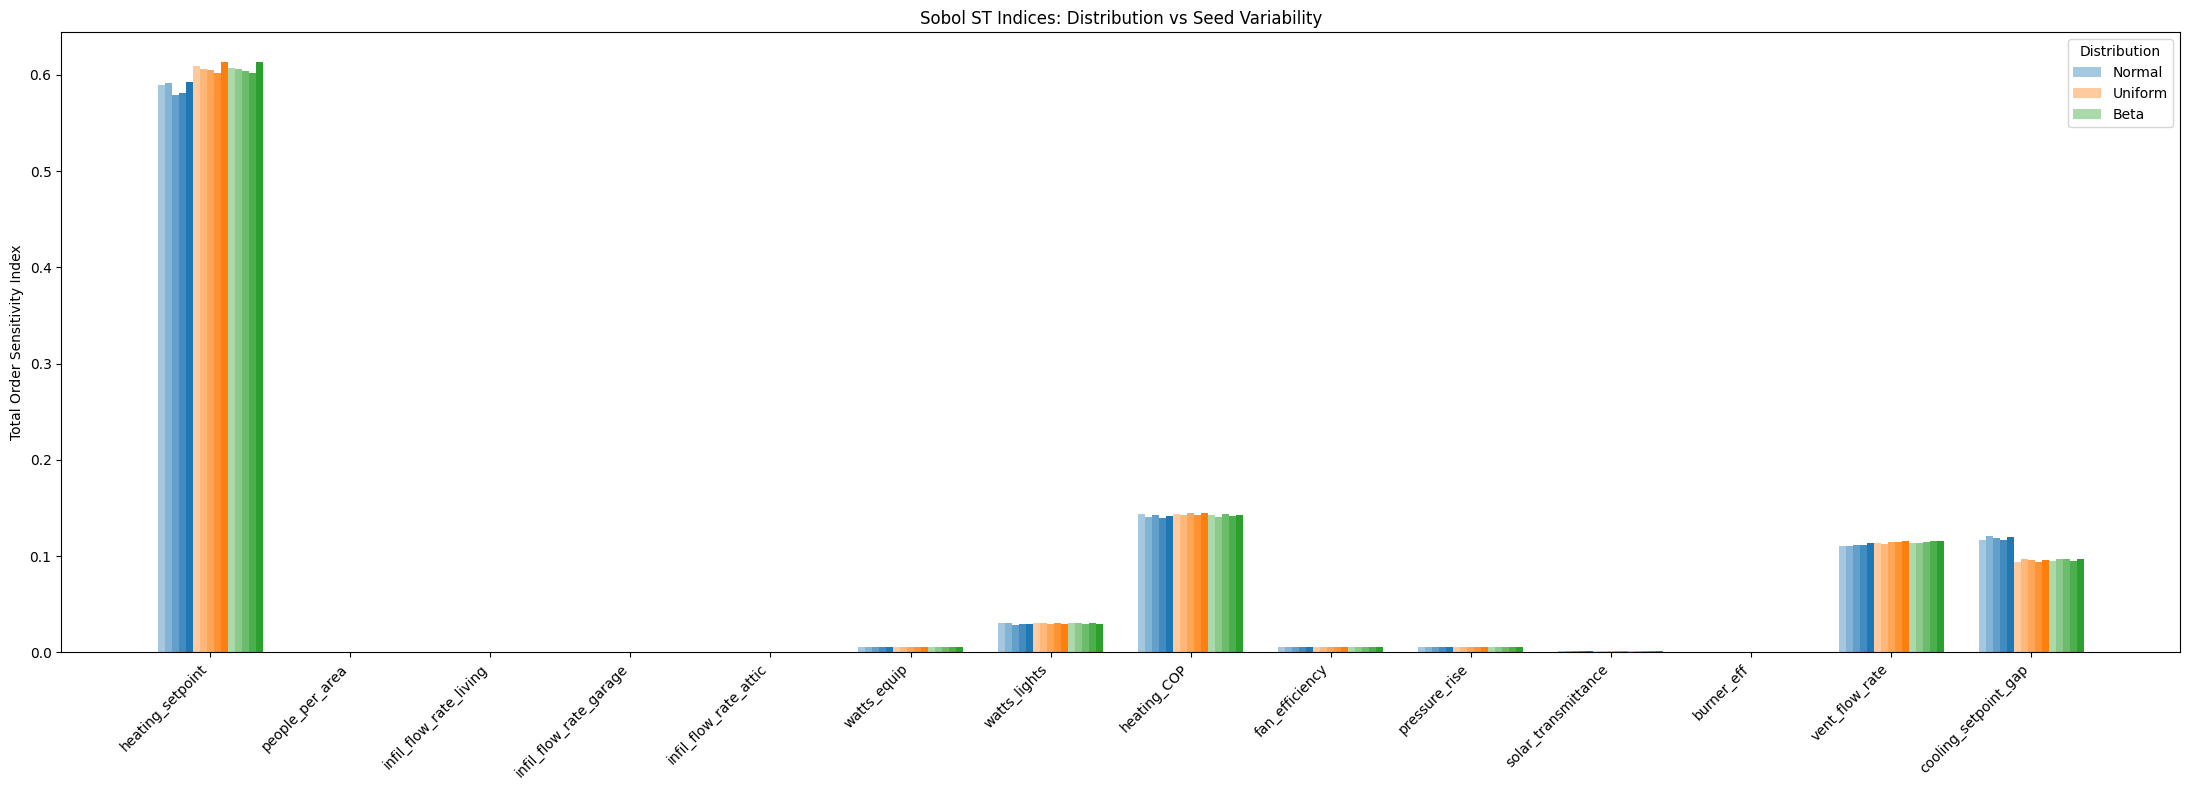

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure long format
plot_df = pd.melt(
    all_indices,
    id_vars=["distribution", "seed"],
    var_name="parameter",
    value_name="ST"
)

# Setup
params = plot_df["parameter"].unique()
distributions = ["Normal", "Uniform", "Beta"]
seeds = sorted(plot_df["seed"].unique())

colors = {
    "Normal": "tab:blue",
    "Uniform": "tab:orange",
    "Beta": "tab:green"
}

fig, ax = plt.subplots(figsize=(22, 8))

x = np.arange(len(params))

bar_width = 0.25
seed_offsets = np.linspace(-0.1, 0.1, len(seeds))
alphas = np.linspace(0.4, 1.0, len(seeds))  # low seed → transparent

# Loop over distributions
for i, dist in enumerate(distributions):

    for j, seed in enumerate(seeds):

        subset = plot_df[
            (plot_df["distribution"] == dist) &
            (plot_df["seed"] == seed)
        ]

        # Align values in correct parameter order
        values = [
            subset.loc[subset["parameter"] == p, "ST"].values[0]
            for p in params
        ]

        ax.bar(
            x + i * bar_width + seed_offsets[j],
            values,
            width=bar_width / len(seeds),
            color=colors[dist],
            alpha=alphas[j],
            label=dist if j == 0 else None
        )

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(params, rotation=45, ha="right")

ax.set_ylabel("Total Order Sensitivity Index")
ax.set_title("Sobol ST Indices: Distribution vs Seed Variability")

ax.legend(title="Distribution")
plt.tight_layout()
plt.show()

#### Sanity Check for Params

In [24]:
unif_params_seed1 = pd.read_csv(f"{work_dir}/params_uniform/simulation_parameters_seed_1.csv")
normal_params_seed1 = pd.read_csv(f"{work_dir}/params_sobol/simulation_parameters_seed_1.csv")

In [10]:
annual_consumption_normal = pd.read_pickle(os.path.join(work_dir, "analysis_sobol", "annual_consumption.pkl"))
annual_consumption_uniform = pd.read_pickle(os.path.join(work_dir, "analysis_uniform", "annual_consumption.pkl"))
annual_consumption_beta = pd.read_pickle(os.path.join(work_dir, "analysis_beta", "annual_consumption.pkl"))

In [13]:
annual_consumption_uniform[0:10]

,Simulation_ID,seed,Electricity:Facility [J](Annual),Electricity:Facility [KJ](Annual),Electricity:Facility [kWh](Annual)
0,1,seed_1,6.101006e+10,6.101006e+07,16947.238986
1,2,seed_1,6.164705e+10,6.164705e+07,17124.179803
2,3,seed_1,6.096338e+10,6.096338e+07,16934.271385
3,4,seed_1,6.078820e+10,6.078820e+07,16885.611709
4,5,seed_1,6.100832e+10,6.100832e+07,16946.756491
5,6,seed_1,6.099191e+10,6.099191e+07,16942.198094
6,7,seed_1,6.135911e+10,6.135911e+07,17044.197480
7,8,seed_1,5.975176e+10,5.975176e+07,16597.710024
8,9,seed_1,6.307370e+10,6.307370e+07,17520.470887
9,10,seed_1,6.077437e+10,6.077437e+07,16881.769739


In [14]:
annual_consumption_normal[0:10]

,Simulation_ID,seed,Electricity:Facility [J](Annual),Electricity:Facility [KJ](Annual),Electricity:Facility [kWh](Annual)
0,1,seed_1,6.190214e+10,6.190214e+07,17195.039313
1,2,seed_1,6.240768e+10,6.240768e+07,17335.467712
2,3,seed_1,6.196318e+10,6.196318e+07,17211.994180
3,4,seed_1,6.178081e+10,6.178081e+07,17161.335941
4,5,seed_1,6.190908e+10,6.190908e+07,17196.966934
5,6,seed_1,6.187005e+10,6.187005e+07,17186.124255
6,7,seed_1,6.215565e+10,6.215565e+07,17265.458896
7,8,seed_1,6.102454e+10,6.102454e+07,16951.261019
8,9,seed_1,6.337982e+10,6.337982e+07,17605.505670
9,10,seed_1,6.176366e+10,6.176366e+07,17156.571764
